# Coffea-Casa Benchmark Example 3
This example shows how to cache chunks' results in Jupyter notebook to be able to rerun only the chunk that failed to produce result during the first run.\
\+ Uses processor.Runner that returns Result type output that is either Ok(Accumulatable) or Err(Exception)

In [1]:
import numpy as np
%matplotlib inline
import hist
import coffea.processor as processor
import awkward as ak
from coffea.nanoevents import schemas
from coffea.util import split_fileset, hash_fileset, load, save

In [2]:
# This program plots an event-level variable (in this case, MET, but switching it is as easy as a dict-key change). It also demonstrates an easy use of the book-keeping cutflow tool, to keep track of the number of events processed.

# The processor class bundles our data analysis together while giving us some helpful tools.  It also leaves looping and chunks to the framework instead of us.
class Processor(processor.ProcessorABC):
    def __init__(self):
        # Bins and categories for the histogram are defined here. For format, see https://coffeateam.github.io/coffea/stubs/coffea.hist.hist_tools.Hist.html && https://coffeateam.github.io/coffea/stubs/coffea.hist.hist_tools.Bin.html
        dataset_axis = hist.axis.StrCategory(name="dataset", label="", categories=[], growth=True)
        MET_axis = hist.axis.Regular(name="MET", label="MET [GeV]", bins=50, start=0, stop=100)
        
        # The accumulator keeps our data chunks together for histogramming. It also gives us cutflow, which can be used to keep track of data.
        self.output = processor.dict_accumulator({
            'MET': hist.Hist(dataset_axis, MET_axis),
            'cutflow': processor.defaultdict_accumulator(int)
        })
    
    def process(self, events):
        # This is where we do our actual analysis. The dataset has columns similar to the TTree's; events.columns can tell you them, or events.[object].columns for deeper depth.
        dataset = events.metadata["dataset"]
        MET = events.MET.pt
        
        # We can define a new key for cutflow (in this case 'all events'). Then we can put values into it. We need += because it's per-chunk (demonstrated below)
        self.output['cutflow']['all events'] += len(MET)
        self.output['cutflow']['number of chunks'] += 1
        
        # This fills our histogram once our data is collected. The hist key ('MET=') will be defined in the bin in __init__.
        self.output['MET'].fill(dataset=dataset, MET=MET)
        return self.output
    
    def postprocess(self, accumulator):
        pass

In [3]:
# from dask.distributed import Client

# client = Client("tls://localhost:8786")

In [4]:
fileset = {'SingleMu_0':
           {"files":  {
             # { "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/01919AD6-5EA0-EB47-B21D-89121FC0C8C6.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/055FA10B-C4F0-BD43-AB89-DDBA00814DF6.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/4DD47A6B-2C21-F142-9929-A351DAFD1473.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/567E763E-F1EF-3745-A1DD-3214C8048EA6.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/715DB643-831D-6D47-8540-63F937CF48F4.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/86F1B4C4-76B0-F949-8DB4-90346A679401.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/953EFAF4-0F31-754C-9601-246C549A2E25.root": "Events",
                # broken link
                "root://eeeeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/C6E8BB7F-7F54-0C4C-9EDF-479C7DBB12E4.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CB90AA65-868A-F548-A291-3837A3113162.root": "Events",
                }
           },
           'SingleMu_1':
           {"files":  {
             # { "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/07D89838-5D7E-CC4E-BD6B-6CA67597D89A.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CF50DAD4-FDE3-D747-A24B-7F7D0B935DE0.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/D5C5C4B1-6A02-5D43-B0C1-16BB2E6145B2.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/F78228AB-4C38-4141-84FE-03928A8D0893.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/0AA3D645-4912-364C-B61D-B41EDD892DE4.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/0F41DD13-E950-5446-A1F1-25DA7AFCB2F5.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/18B53494-657F-5744-8131-58ABA4EE00ED.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/2CCE1139-F301-C341-AE1E-4D27AF294018.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/300C603C-F1DD-4A40-B4DD-F4E0B239A460.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/39251543-EE21-9C4C-80D5-5D9178F55C71.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/3BD29D89-9C4A-E743-8616-C6806281BF12.root": "Events",
            }
           }
          }

# executor = processor.DaskExecutor(client=client)
executor = processor.FuturesExecutor()

run = processor.Runner(executor=executor,
                        schema=schemas.NanoAODSchema,
                        savemetrics=True
                      )

import pprint

chunks = split_fileset(fileset, percentage=20)
pprint.pprint(chunks)


[{'SingleMu_0': {'files': {'root://eeeeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events'}},
  'SingleMu_1': {'files': {'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/18B53494-657F-5744-8131-58ABA4EE00ED.root': 'Events'}}},
 {'SingleMu_0': {'files': {'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events'}},
  'SingleMu_1': {'files': {'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_

In [5]:
import os

result = None
cache_dir = "./chunk_cache"
os.makedirs(cache_dir, exist_ok=True)

In [6]:
# percentage=20, 5 mixed chunks: 1st chunk is 20% of SingleMu_0 + 20% of SingleMu_1 ...
for chunk in chunks:
    chunk_hash = hash_fileset(chunk)
    cache_path = os.path.join(cache_dir, f"{chunk_hash}.coffea")

    if os.path.exists(cache_path):
        print(f"Loading cached result for chunk {chunk_hash}")
        output = load(cache_path)
    else:
        run_result = run(chunk, processor_instance=Processor())
        if run_result.is_ok():
            output, metrics = run_result.unwrap()
            save(output, cache_path)
            print(f"Saved result for chunk {chunk_hash}")
        else:
            # user can implement their own logic on how to treat failed chunks
            print(f"Error processing chunk {chunk_hash}: {run_result.exception}")
            continue

    if result is None:
        result = output
    else:
        result += output

Output()

/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py:1167: UserWarning: Performed attempt 1 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1181, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1165, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1235, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Error processing chunk cea698fb66fb3e9d65297dbe1491bba8a267d7eb0f99f18c78852244e7d82cee: Failed to submit <bound method File.open of <XRootD.client.file.File object at 0x7ff1eff92de0>> request: [FATAL] Invalid address


Output()

...

Output()

Saved result for chunk 7df98284924bbe6600b8a31b3c44e4f43e76a6d4b4dd7dae26e1f54fffe1cd20


Output()

Output()

Saved result for chunk aeab620f36da8ac9fcfdf5bf319e8921f3bf8865874e5e28e88e2a48bde669bf


### After the first run the first chunk analysis failed, but the rest 4 chunks produced result and we cached it. So during the next rerun the code only retried to process the chunk that wasn't found in cache. The rest of the data was extracted from cache files.

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7cfeda8710>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7cfedece00>, errorbar=None, legend_artist=None)]

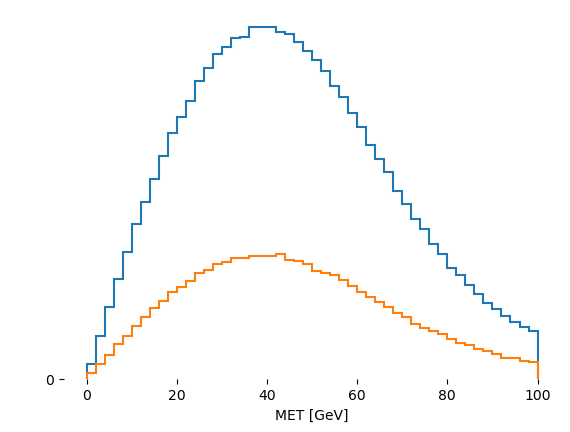

In [7]:
# Generates a 1D histogram from the data output to the 'MET' key. fill_opts are optional, to fill the graph (default is a line).
result['MET'].plot1d()

In [8]:
# Easy way to print all cutflow dict values. Can just do print(output['cutflow']["KEY_NAME"]) for one.
for key, value in result['cutflow'].items():
    print(key, value)

all events 1292000
number of chunks 16
